# Análisis de factores asociados a crímenes violentos (Communities & Crime)

## Temática y fuente

Los datos combinan datos socioeconómicos del censo de 1990, datos de aplicación de la ley de la encuesta de gestión y estadísticas administrativas de aplicación de la ley de 1990 y datos sobre delincuencia de la UCR.

El dataset se obtuvo desde https://archive.ics.uci.edu/dataset/211/communities+and+crime+unnormalized







## Información adicional sobre el Dataset

Los conjuntos de datos de origen debían combinarse mediante programación. Se incluyen muchas variables para poder probar algoritmos que seleccionan o aprenden pesos para atributos. Sin embargo, no se incluyeron atributos claramente no relacionados; se eligieron atributos si había alguna conexión plausible con el delito (N=125), más las variables del delito que son variables dependientes potenciales. Las variables incluidas en el conjunto de datos involucran a la comunidad, como el porcentaje de la población considerada urbana y el ingreso familiar medio, e involucran a las fuerzas del orden, como el número per cápita de agentes de policía y el porcentaje de agentes asignados a unidades de drogas. Los atributos delictivos (N=18) que podrían predecirse son los 8 delitos considerados 'delitos índice' por el FBI) (asesinatos, violaciones, robos, .... ), versiones per cápita (en realidad por cada 100.000 habitantes) de cada uno,y Delitos Violentos Per Capita y Delitos No Violentos Per Capita).
  
Una limitación fue que la encuesta LEMAS se realizó en los departamentos de policía con al menos 100 oficiales, más una muestra aleatoria de departamentos más pequeños. Para nuestros propósitos, se omitieron las comunidades que no se encuentran en los conjuntos de datos censales y sobre delincuencia. A muchas comunidades les faltan datos de LEMAS.

Las variables de delitos per cápita se calcularon utilizando valores de población incluidos en los datos del FBI de 1995 (que difieren de los valores del censo de 1990).

La variable delitos violentos per cápita se calculó utilizando la población y la suma de las variables delictivas consideradas delitos violentos en los Estados Unidos: asesinato, violación, robo y agresión. Al parecer hubo cierta controversia en algunos estados sobre el recuento de violaciones. Esto dio lugar a que faltaran valores para la violación,lo que dio lugar a que faltaran valores para los delitos violentos per cápita. Muchas de estas comunidades omitidas eran del medio oeste de Estados Unidos (Minnesota, Illinois y Michigan tienen muchas de ellas).  
  
La variable de delitos no violentos per cápita se calculó utilizando la suma de las variables delictivas consideradas delitos no violentos en Estados Unidos: robos, hurtos, hurtos de automóviles e incendios provocados. (Existen muchos otros tipos de delitos, entre los que sólo se incluyen los 'delitos índice' del FBI)



## Objetivo

La **variable target** del estudio es **`ViolentCrimesPerPop`**, que representa la **proporción de crímenes violentos por habitante** (valor normalizado entre 0 y 1).  
El propósito central del análisis es **identificar los factores socioeconómicos y demográficos más asociados a la violencia** y evaluar la capacidad de distintos **modelos de regresión** para predecir esta variable.


## Preguntas a responder

- ¿Qué variables sociodemográficas se asocian más con `ViolentCrimesPerPop`?
- ¿La pobreza, educación o estructura familiar influyen en el crimen?
- ¿Se pueden agrupar comunidades con perfiles de riesgo similares?
- ¿Podemos predecir correctamente comunidades con alta tasa de crímenes violentos?

# Data wrangling

## Bloques de códigos

In [39]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings('ignore')

# Liberias para realizar graficas
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [3]:
url = 'https://drive.google.com/file/d/1U1B0kG40_1uLM3Pu28LkzKT42jGt25RN/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
df_orig = pd.read_csv(path, na_values=['?'], header=None)

In [4]:
print("Dimensión inicial:", df_orig.shape)

Dimensión inicial: (2215, 147)


In [5]:
df_orig.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,137,138,139,140,141,142,143,144,145,146
1563,Carytown,NC,NaN,NaN,8,43858,2.59,5.51,89.78,3.84,...,367.0,593.38,1366.0,2208.60,66.0,106.71,21.0,33.95,161.68,2942.65
414,Highlandcity,CA,NaN,NaN,2,34439,3.04,10.97,73.14,4.81,...,699.0,1773.57,951.0,2412.97,371.0,941.34,12.0,30.45,880.44,5158.33
1495,Hollistontown,MA,17.0,30700.0,7,12926,3.02,1.02,97.75,0.95,...,23.0,171.64,83.0,619.40,4.0,29.85,0.0,0.00,59.70,820.90
105,Redlandscity,CA,NaN,NaN,1,60394,2.75,3.83,79.59,4.42,...,975.0,1503.47,1620.0,2498.07,616.0,949.88,16.0,24.67,727.83,4976.10
2169,SilverCitytown,NM,NaN,NaN,10,10683,2.76,0.93,93.01,0.49,...,134.0,1143.05,569.0,4853.71,20.0,170.60,6.0,51.18,597.12,6218.54
274,Johnstontown,RI,7.0,37720.0,2,26542,2.66,0.57,98.69,0.57,...,190.0,693.96,577.0,2107.45,148.0,540.56,5.0,18.26,91.31,3360.24
691,ElRenocity,OK,NaN,NaN,4,15414,2.89,9.00,80.73,0.54,...,184.0,1157.52,453.0,2849.77,57.0,358.58,18.0,113.24,509.56,4479.11
972,DeLandcity,FL,NaN,NaN,5,16491,2.46,21.90,76.14,0.41,...,630.0,3437.18,1548.0,8445.63,158.0,862.02,4.0,21.82,1964.10,12766.65
1432,Grandviewcity,MO,NaN,NaN,7,24967,2.69,16.95,80.88,0.94,...,296.0,1156.52,445.0,1738.69,137.0,535.28,5.0,19.54,418.07,3450.03
489,Alamedacity,CA,NaN,NaN,3,76459,2.63,6.72,69.91,19.25,...,769.0,972.59,3278.0,4145.85,479.0,605.82,46.0,58.18,599.49,5782.44


In [6]:
df_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Columns: 147 entries, 0 to 146
dtypes: float64(116), int64(29), object(2)
memory usage: 2.5+ MB


In [7]:
df_orig.isna().sum()

,0
0,0
1,0
2,1221
3,1224
4,0
...,...
142,3
143,91
144,91
145,221


In [8]:
df_orig.describe(percentiles=[i/10 for i in range(1, 10)])

,2,3,4,5,6,7,8,9,10,11,...,137,138,139,140,141,142,143,144,145,146
count,994.000000,991.000000,2215.000000,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,...,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2124.000000,2124.000000,1994.000000,2118.000000
mean,65.587525,45209.251261,5.494357,5.311798e+04,2.707327,9.335102,83.979819,2.670203,7.950176,14.445837,...,761.236890,1033.430203,2137.629295,3372.979150,516.692586,473.965628,30.907721,32.153682,589.078922,4908.241804
std,117.831399,25425.861573,2.872924,2.046203e+05,0.334120,14.247156,16.419080,4.473843,14.589832,4.518623,...,3111.702756,763.354442,7600.573464,1901.316145,3258.164244,504.666026,180.125248,39.240900,614.784518,2739.708901
min,1.000000,70.000000,1.000000,1.000500e+04,1.600000,0.000000,2.680000,0.030000,0.120000,4.580000,...,2.000000,16.920000,10.000000,77.860000,1.000000,6.550000,0.000000,0.000000,0.000000,116.790000
10%,3.000000,8364.000000,1.400000,1.153080e+04,2.380000,0.340000,59.848000,0.370000,0.560000,10.934000,...,56.000000,333.576000,229.000000,1379.917000,14.000000,87.603000,0.000000,0.000000,80.156000,2009.564000
20%,9.000000,18448.000000,2.000000,1.322680e+04,2.470000,0.670000,72.656000,0.530000,0.790000,11.890000,...,81.000000,457.818000,339.000000,1810.722000,24.000000,134.288000,1.000000,5.628000,133.560000,2659.746000
30%,15.000000,28875.000000,3.000000,1.557400e+04,2.530000,1.060000,80.176000,0.712000,1.070000,12.572000,...,111.000000,563.507000,453.000000,2241.432000,35.000000,180.123000,2.000000,9.160000,203.654000,3194.233000
40%,21.000000,38740.000000,4.000000,1.877600e+04,2.590000,1.660000,86.218000,0.940000,1.530000,13.140000,...,156.400000,694.088000,577.000000,2647.494000,51.000000,236.998000,3.000000,15.006000,278.432000,3842.878000
50%,27.000000,46925.000000,5.000000,2.279200e+04,2.660000,2.870000,90.350000,1.230000,2.180000,13.620000,...,205.000000,822.715000,747.000000,3079.510000,75.000000,302.355000,5.000000,21.080000,374.060000,4425.450000
60%,39.000000,54214.000000,6.000000,2.823980e+04,2.730000,4.860000,93.260000,1.640000,3.244000,14.144000,...,282.600000,999.832000,992.000000,3526.608000,108.600000,380.164000,8.000000,27.898000,501.828000,5063.886000


## Columnas





 Este dataset original (UCI Communities & Crime) no trae headers en el archivo crudo, si traigo información desde API queda incompleto el encabezado, entonces, agrego el encabezado a traves del diccionario.



## API

In [9]:
# de la página desde donde extraje el dataset, traigo información de las variables
# para nombrar las columnas del data
df = pd.read_html('https://archive.ics.uci.edu/dataset/211/communities+and+crime+unnormalized')
type(df)

list

In [10]:
len(df)

2

In [11]:
df[0]

,Variable Name,Role,Type,Demographic,Description,Units,Missing Values
0,communityname,ID,Categorical,NaN,NaN,NaN,no
1,State,Feature,Categorical,NaN,NaN,NaN,no
2,countyCode,ID,Integer,NaN,NaN,NaN,yes
3,communityCode,ID,Integer,NaN,NaN,NaN,yes
4,fold,ID,Integer,NaN,NaN,NaN,no
5,pop,Feature,Integer,NaN,NaN,NaN,no
6,perHoush,Feature,Continuous,NaN,NaN,NaN,no
7,pctBlack,Feature,Continuous,Race,NaN,NaN,no
8,pctWhite,Feature,Continuous,Race,NaN,NaN,no
9,pctAsian,Feature,Continuous,Race,NaN,NaN,no


No viene la información completa ya que está dividida en varias páginas.

In [12]:
# con la lista extraida de la página, armo un diccionario

arch_url = 'https://docs.google.com/spreadsheets/d/1UAcf5aMDKFqOaYKc5OngAjdH_3SSFcfe/edit?usp=drive_link&ouid=116161815519757514283&rtpof=true&sd=true'
arch_id = arch_url.split('/')[-2]
down_url = f'https://docs.google.com/spreadsheets/d/{arch_id}/export?firmat=xlsx'

diccionario_variables = pd.read_excel(down_url)
diccionario_variables.sample(30)

,Variable,Descripción,Tipo
29,AsianPerCap,Ingreso per cápita para personas con ascendenc...,decimal
63,PctRecImmig8,Porcentaje de la población que ha inmigrado en...,decimal
7,racepctblack,Porcentaje de la población afroamericana,decimal
34,PctLess9thGrade,Porcentaje de personas de 25 años o más con me...,decimal
56,NumImmig,Número total de personas que se sabe que nacie...,integer
54,NumKidsBornNeverMar,Número de hijos nacidos y nunca casados,integer
88,RentLowQ,Vivienda de alquiler - alquiler cuartil inferior,decimal
142,autoTheftPerPop,Número de robos de automóviles por cada 100 mi...,decimal
52,PctWorkMomYoungKids,Porcentaje de madres de niños menores de 6 año...,decimal
146,nonViolPerPop,Número total de delitos no violentos por cada ...,decimal


In [13]:
# Al tener las variales indicadas en el diccionario, busco darle un encabazado al data original
columns_names = diccionario_variables ['Variable'].tolist()

In [14]:
len(columns_names) == len(df_orig.columns)

True

In [15]:
df_orig.columns = columns_names

In [16]:
df_orig.sample(10)

,communityname,state,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop
910,Morgantoncity,NC,NaN,NaN,5,15085,2.49,15.37,83.00,1.38,...,246.0,1391.64,876.0,4955.59,39.0,220.63,2.0,11.31,503.48,6579.17
394,Glendoracity,CA,NaN,NaN,2,47828,2.93,1.12,88.49,5.62,...,474.0,907.73,1076.0,2060.59,191.0,365.77,7.0,13.41,294.92,3347.50
1166,CliffsideParkborough,NJ,3.0,13570.0,6,20393,2.32,1.81,88.15,7.45,...,64.0,305.58,231.0,1102.94,56.0,267.38,0.0,0.00,124.14,1675.90
968,Northportcity,AL,NaN,NaN,5,17366,2.66,22.83,75.96,0.92,...,130.0,637.50,711.0,3486.66,29.0,142.21,NaN,NaN,853.28,NaN
1169,Palatinevillage,IL,NaN,NaN,6,39253,2.59,0.94,94.25,3.25,...,197.0,420.26,999.0,2131.15,42.0,89.60,3.0,6.40,NaN,2647.41
1807,Wilkinsburgborough,PA,3.0,85188.0,9,21080,2.14,52.54,46.20,0.58,...,344.0,1691.42,432.0,2124.10,347.0,1706.17,11.0,54.09,2586.29,5575.77
1766,WestMifflinborough,PA,3.0,83512.0,8,23644,2.45,7.45,92.17,0.22,...,94.0,401.47,535.0,2284.96,379.0,1618.69,3.0,12.81,469.80,4317.93
1066,Butlercity,PA,19.0,10464.0,5,15714,2.28,1.40,97.70,0.41,...,68.0,401.82,400.0,2363.65,40.0,236.36,4.0,23.64,212.73,3025.47
860,Cinnaminsontownship,NJ,5.0,12940.0,4,14583,3.06,5.29,92.35,1.78,...,94.0,629.77,271.0,1815.62,82.0,549.38,0.0,0.00,247.89,2994.77
2023,Arkadelphiacity,AR,NaN,NaN,10,10014,2.90,25.66,73.09,0.55,...,24.0,226.14,271.0,2553.47,14.0,131.91,0.0,0.00,47.11,2911.52


Busco valores nulos o faltantes con el encabezado integrado

Creamos un heatmap de valores faltantes para visualizar las variables con valores nulos o faltantes

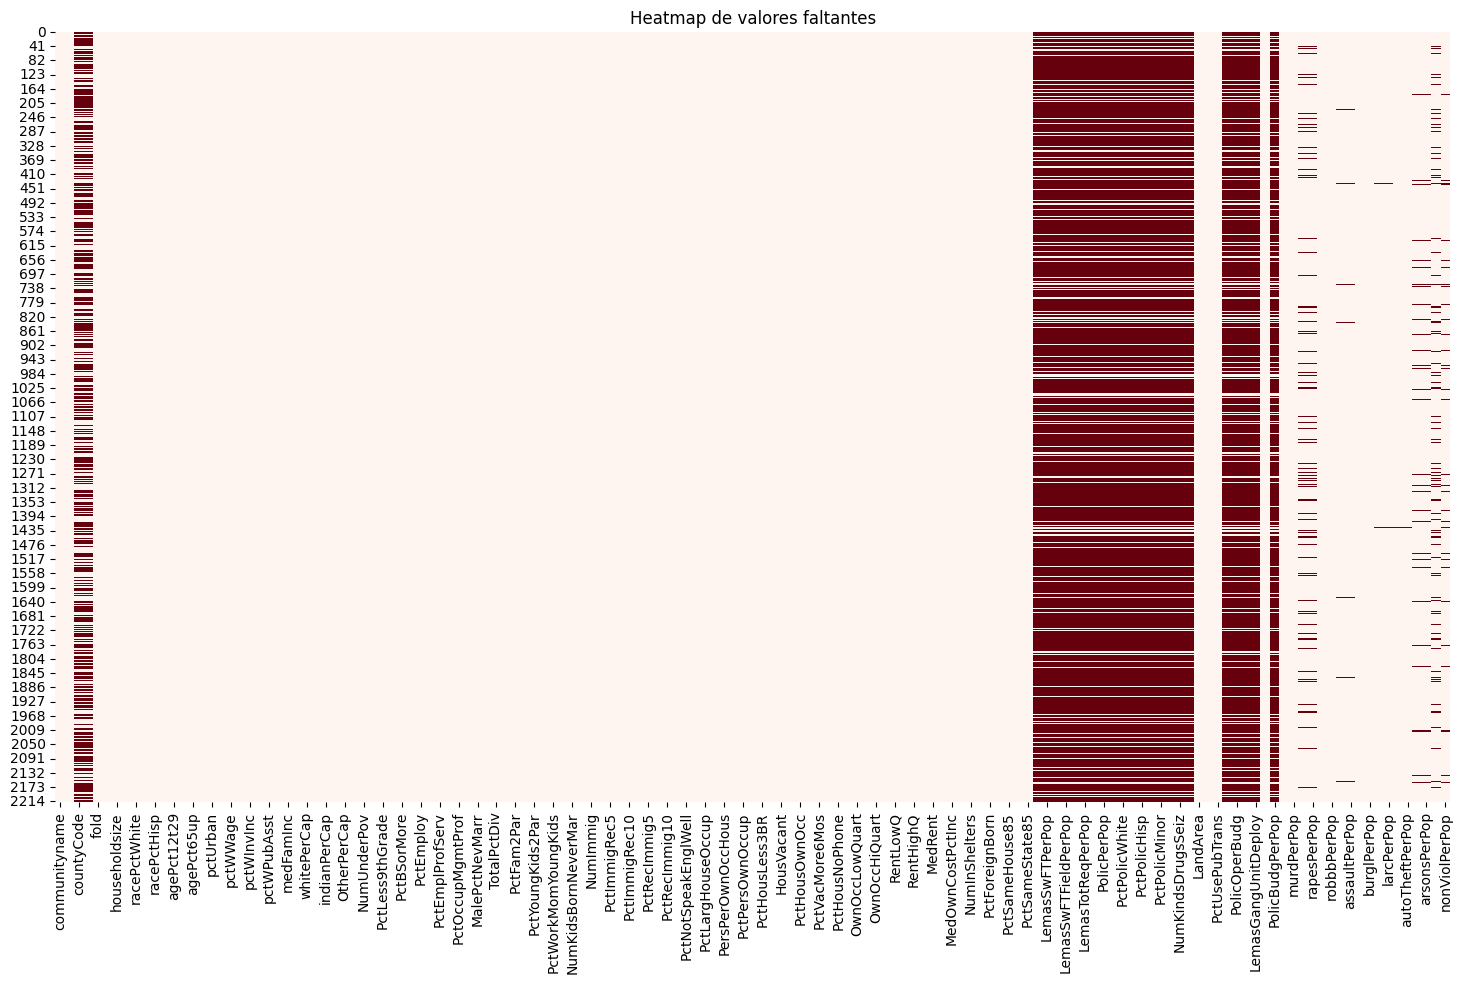

In [17]:
plt.figure(figsize=(18, 10))
sns.heatmap(df_orig.isnull(), cbar=False, cmap='Reds')
plt.title("Heatmap de valores faltantes")
plt.show()

Verificamos si hay datos duplicados

In [18]:
df_orig[df_orig.duplicated() == True]

,communityname,state,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop


Sin valores duplicados

Evaluamos el porcentaje de datos perdidos o nulos

In [19]:
perd_nul= df_orig.isna().mean().sort_values(ascending=False)
perd_nul.sample(30)


,0
PctSameCity85,0.000000
ViolentCrimesPerPop,0.099774
LandArea,0.000000
indianPerCap,0.000000
PctLargHouseFam,0.000000
PctTeen2Par,0.000000
RentLowQ,0.000000
racepctblack,0.000000
population,0.000000
PersPerOwnOccHous,0.000000


Limpieza de columnas que no aportan información para el objetivo y modificación de tipos de datos

In [20]:
thresh = 0.8  # Porcentaje de datos nulos o perdidos de referencia
elim_cols = perd_nul[perd_nul > thresh].index.tolist()
print('Eliminar columnas (>80% missing):', elim_cols) # se eliminan columnas con 80% nulos/perd
df_Col_final = df_orig.drop(columns=elim_cols).copy()


Eliminar columnas (>80% missing): ['PctPolicBlack', 'PolicReqPerOffic', 'PolicPerPop', 'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr', 'PolicAveOTWorked', 'LemasGangUnitDeploy', 'PolicBudgPerPop', 'PctPolicWhite', 'RacialMatchCommPol', 'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'NumKindsDrugsSeiz', 'OfficAssgnDrugUnits', 'PctPolicMinor', 'PctPolicAsian', 'LemasTotReqPerPop', 'LemasTotalReq', 'PctPolicHisp']


In [21]:
for c in df_Col_final.columns:
    if df_Col_final[c].dtype == object and c not in ['state','countyCode','communityCode','communityname','fold']:
        df_Col_final[c] = pd.to_numeric(df_Col_final[c], errors='coerce') # Convierte los valores numéricos en NaN


Elimino otras columnas que no son de interes

In [22]:
otras_col_no_interes = ['state', 'countyCode', 'communityCode', 'communityname', 'fold']
df_Col_final = df_Col_final.drop(columns=otras_col_no_interes)

Verificación de cambios

In [23]:
print(df_Col_final.dtypes)

population               int64
householdsize          float64
racepctblack           float64
racePctWhite           float64
racePctAsian           float64
                        ...   
autoTheftPerPop        float64
arsons                 float64
arsonsPerPop           float64
ViolentCrimesPerPop    float64
nonViolPerPop          float64
Length: 120, dtype: object


In [24]:
df_Col_final.describe(percentiles=[i/10 for i in range(1, 10)]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
population,2215.0,53117.984199,204620.252853,10005.00,11530.800,13226.800,15574.000,18776.000,22792.000,28239.800,36413.800,51567.600,85490.200,7322564.00
householdsize,2215.0,2.707327,0.334120,1.60,2.380,2.470,2.530,2.590,2.660,2.730,2.800,2.900,3.070,5.28
racepctblack,2215.0,9.335102,14.247156,0.00,0.340,0.670,1.060,1.660,2.870,4.860,8.296,15.594,29.318,96.67
racePctWhite,2215.0,83.979819,16.419080,2.68,59.848,72.656,80.176,86.218,90.350,93.260,95.288,97.010,98.086,99.63
racePctAsian,2215.0,2.670203,4.473843,0.03,0.370,0.530,0.712,0.940,1.230,1.640,2.230,3.450,6.082,57.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
autoTheftPerPop,2212.0,473.965628,504.666026,6.55,87.603,134.288,180.123,236.998,302.355,380.164,515.572,705.442,1103.735,4968.59
arsons,2124.0,30.907721,180.125248,0.00,0.000,1.000,2.000,3.000,5.000,8.000,12.000,20.000,44.700,5119.00
arsonsPerPop,2124.0,32.153682,39.240900,0.00,0.000,5.628,9.160,15.006,21.080,27.898,37.742,49.734,74.432,436.37
ViolentCrimesPerPop,1994.0,589.078922,614.784518,0.00,80.156,133.560,203.654,278.432,374.060,501.828,673.689,935.200,1420.736,4877.06


In [42]:
print(f"Columnas originales: {df_orig.shape[1]} → Columnas finales: {df_Col_final.shape[1]}")

Columnas originales: 147 → Columnas finales: 120


In [25]:
print("Dimención final:", df_Col_final.shape)

Dimención final: (2215, 120)


# Análisis exploratorio de los datos (EDA)

## Distribución de la variable target

In [26]:
if 'ViolentCrimesPerPop' in df_Col_final.columns:
    target = 'ViolentCrimesPerPop'
else:
    target = df_Col_final.columns[-1]

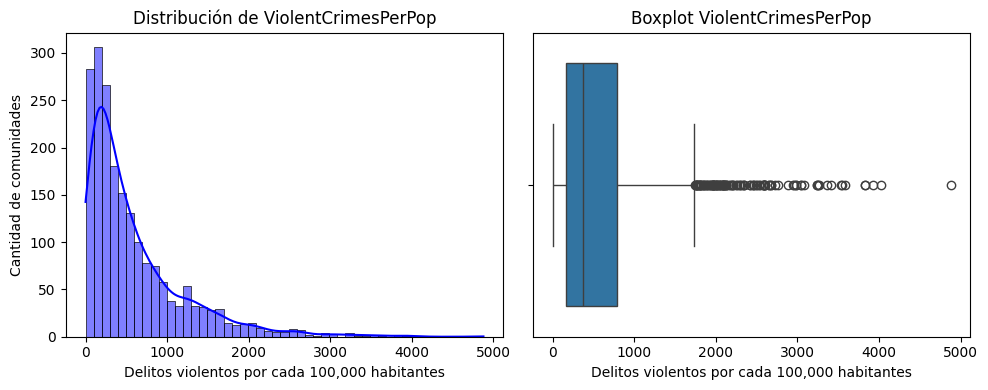

In [46]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df_Col_final[target].dropna(), kde=True, color='blue')
plt.title('Distribución de ' + target)
plt.xlabel('Delitos violentos por cada 100,000 habitantes')
plt.ylabel('Cantidad de comunidades')
plt.subplot(1,2,2)
sns.boxplot(x=df_Col_final[target])
plt.title('Boxplot ' + target)
plt.xlabel('Delitos violentos por cada 100,000 habitantes')
plt.tight_layout()

Se observa que la variable muestra una fuerte asimetría positiva: la mayoría de las comunidades tienen baja tasa de delitos, pero unas pocas presentan valores muy altos.
Se observan outliers que podrían corresponder a comunidades con alto riesgo social o urbano.

## ¿Qué variables sociodemográficas se asocian más con ViolentCrimesPerPop?

Text(0.5, 0, 'Correlación absoluta')

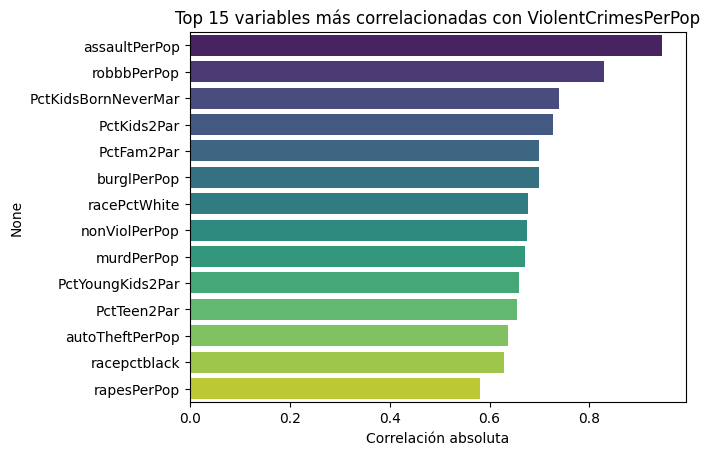

In [28]:
numeric_cols = df_Col_final.select_dtypes(include=np.number).columns
corr = df_Col_final[numeric_cols].corr()[target].abs().sort_values(ascending=False)
top_corr = corr[1:15]
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title('Top 15 variables más correlacionadas con ViolentCrimesPerPop')
plt.xlabel('Correlación absoluta')

Las variables más correlacionadas con ViolentCrimesPerPop corresponden principalmente a otros tipos de delitos violentos (assaultPerPop, robbrPerPop, murdPerPop, rapesPerPop), lo cual resulta coherente al tratarse de componentes de la misma categoría.
También se observan variables asociadas a la estructura familiar, como PctKidsBornNeverMar (niños nacidos de padres no casados) y PctFam2Par (familias biparentales), que reflejan posibles factores sociales relacionados con la criminalidad.
En cambio, las variables socioeconómicas como pobreza o educación presentan correlaciones más moderadas, aunque siguen siendo relevantes en un análisis más amplio.

## ¿La pobreza, educación o estructura familiar influyen en el crimen?

Selección de variables socioeconómicas y demográficas relevantes para responder a la pregunta y evaluamos cómo se relaciona ViolentCrimesPerPop con variables sociodemográficas (pobreza, educación, familia, etc.).

Variables incluidas en el análisis: ['ViolentCrimesPerPop', 'PctPopUnderPov', 'PctNotHSGrad', 'PctKidsBornNeverMar', 'PctFam2Par', 'PctKids2Par']


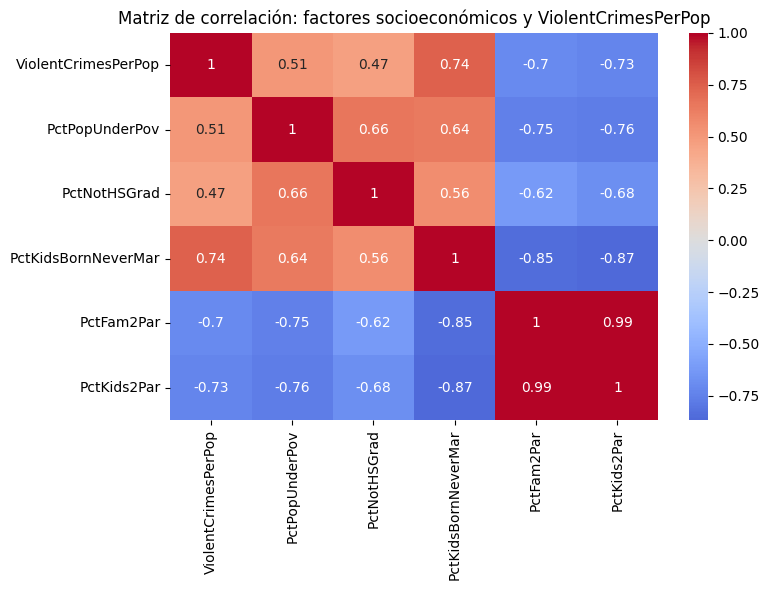

In [29]:
selected = [
    'ViolentCrimesPerPop',  # Variable targuet
    'PctPopUnderPov',       # Bajo la línea de pobreza
    'PctNotHSGrad',         # Personas de 25 años o más que no son graduados de la escuela secundaria
    'PctKidsBornNeverMar',  # Niños nacidos y nunca casados
    'PctFam2Par',           # Familias (con hijos) encabezadas por dos padres
    'PctKids2Par',          # Niños en viviendas familiares con dos padres
    'MedIncome'             # Ingreso familiar promedio
]

# Verificamos que las columnas existan en el DataFrame (por si hay diferencias de nombres)
selected = [c for c in selected if c in df_Col_final.columns]
print("Variables incluidas en el análisis:", selected)

# Creamos la matriz de correlación
plt.figure(figsize=(8,6))
sns.heatmap(df_Col_final[selected].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación: factores socioeconómicos y ViolentCrimesPerPop')
plt.tight_layout()
plt.show()

La correlación entre las variables analizadas indica que los factores sociodemográficos desempeñan un rol central en los niveles de criminalidad violenta.
La pobreza, la baja educación y la desintegración familiar están asociadas con mayores tasas de crimen, mientras que la estabilidad familiar y el ingreso medio parecen actuar como factores protectores.
Estas relaciones sugieren que políticas públicas orientadas a mejorar la educación, reducir la pobreza y fortalecer el núcleo familiar podrían contribuir a disminuir la violencia en las comunidades.

## ¿Se pueden agrupar comunidades con perfiles de riesgo similares?

Text(0.5, 1.02, 'Relaciones multivariadas entre factores socioeconómicos y crimen violento')

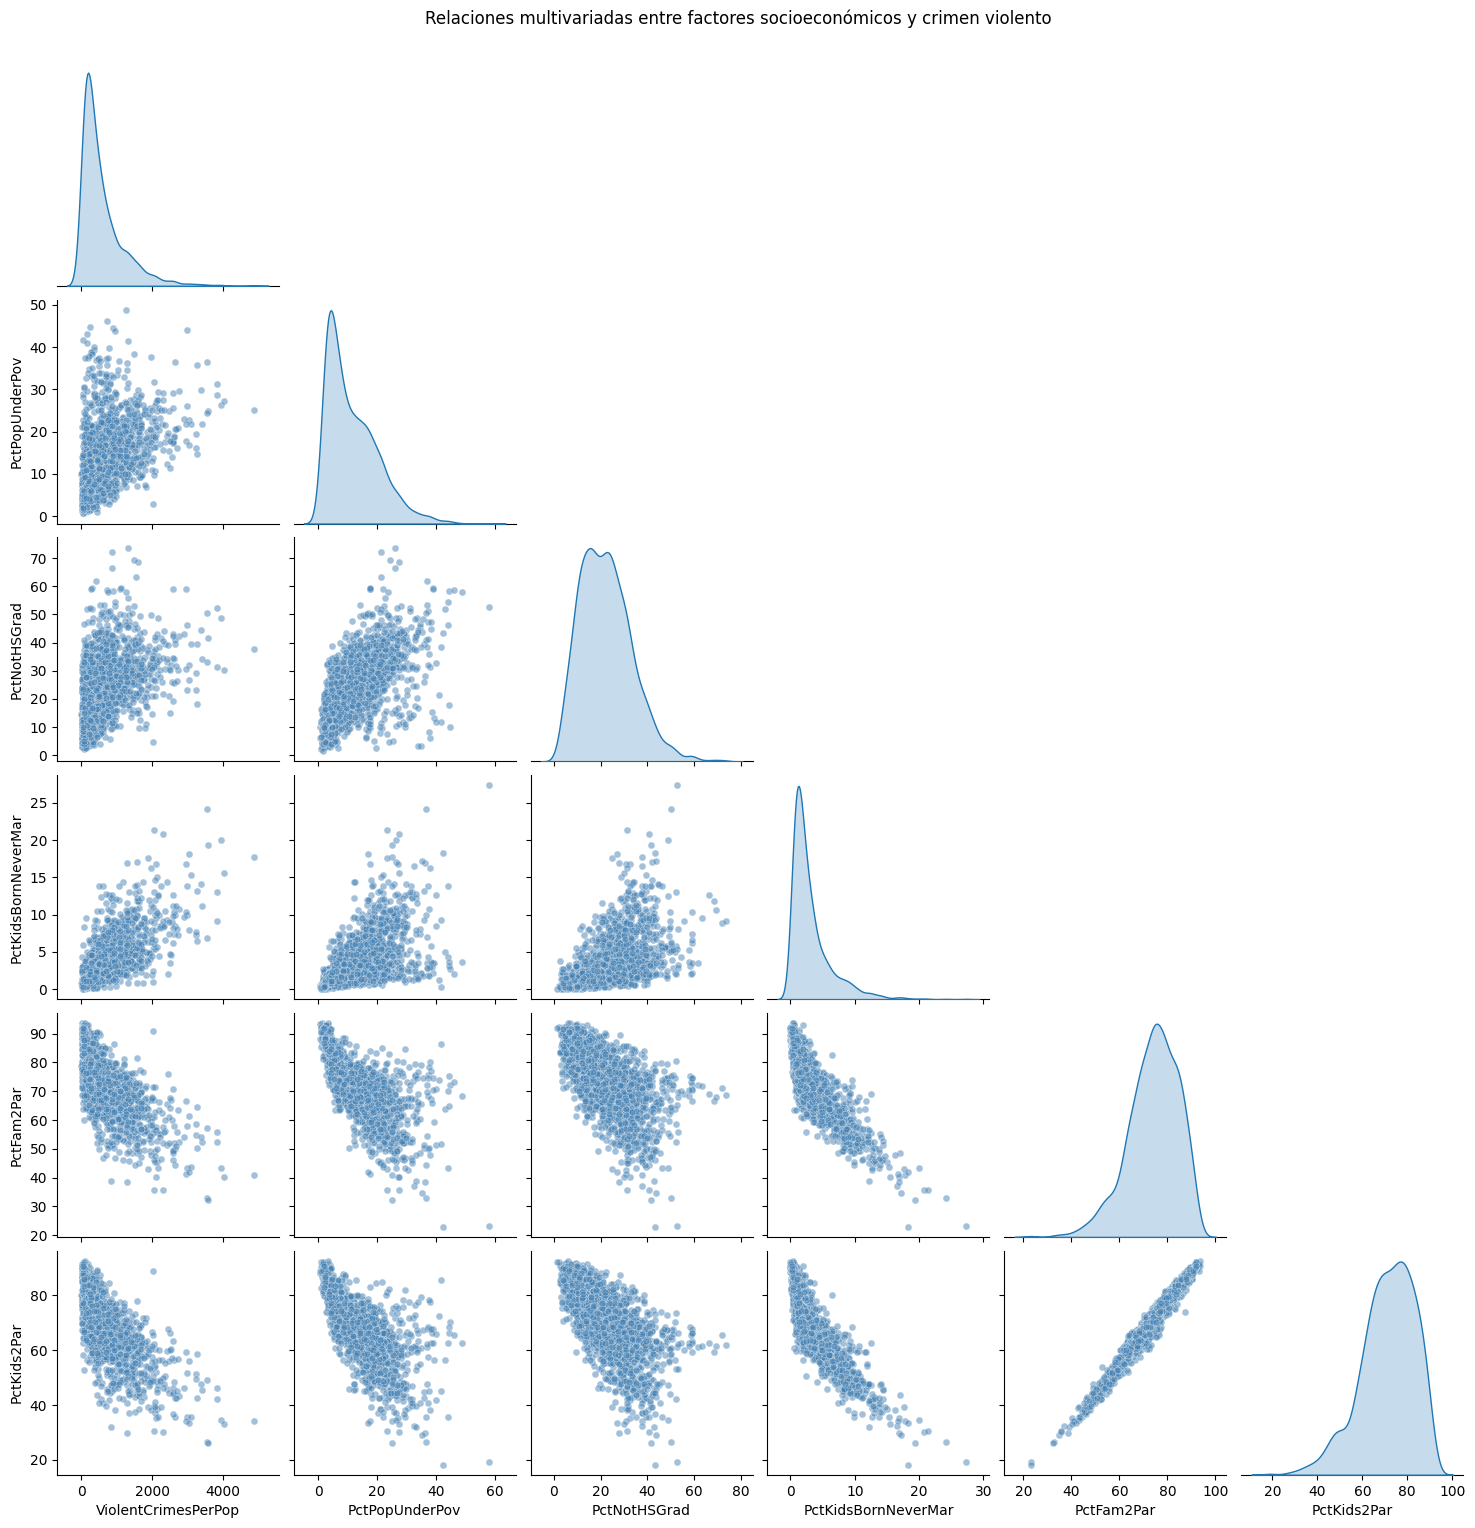

In [49]:
selected = ['ViolentCrimesPerPop','PctPopUnderPov','PctNotHSGrad','PctKidsBornNeverMar','PctFam2Par','PctKids2Par']
sns.pairplot(df_Col_final[selected], diag_kind='kde', corner=True, plot_kws={'alpha':0.5, 's':25, 'color':'steelblue'})
plt.suptitle('Relaciones multivariadas entre factores socioeconómicos y crimen violento', y=1.02)

El análisis multivariado evidencia que los niveles de crimen violento están asociados a un conjunto de factores socioeconómicos interrelacionados.
Las comunidades con mayor pobreza, menor nivel educativo y mayor proporción de familias desintegradas presentan consistentemente tasas más altas de violencia.
Por el contrario, aquellas con mayor estabilidad familiar y mejores condiciones socioeconómicas exhiben niveles significativamente más bajos.

Estos resultados indican que la violencia no depende de un solo factor, sino de una combinación de vulnerabilidades sociales.
Abordar el problema requiere intervenciones integrales, orientadas a educación, reducción de la pobreza y fortalecimiento familiar.

Text(0.5, 1.0, 'Agrupamiento de variables según correlaciones')

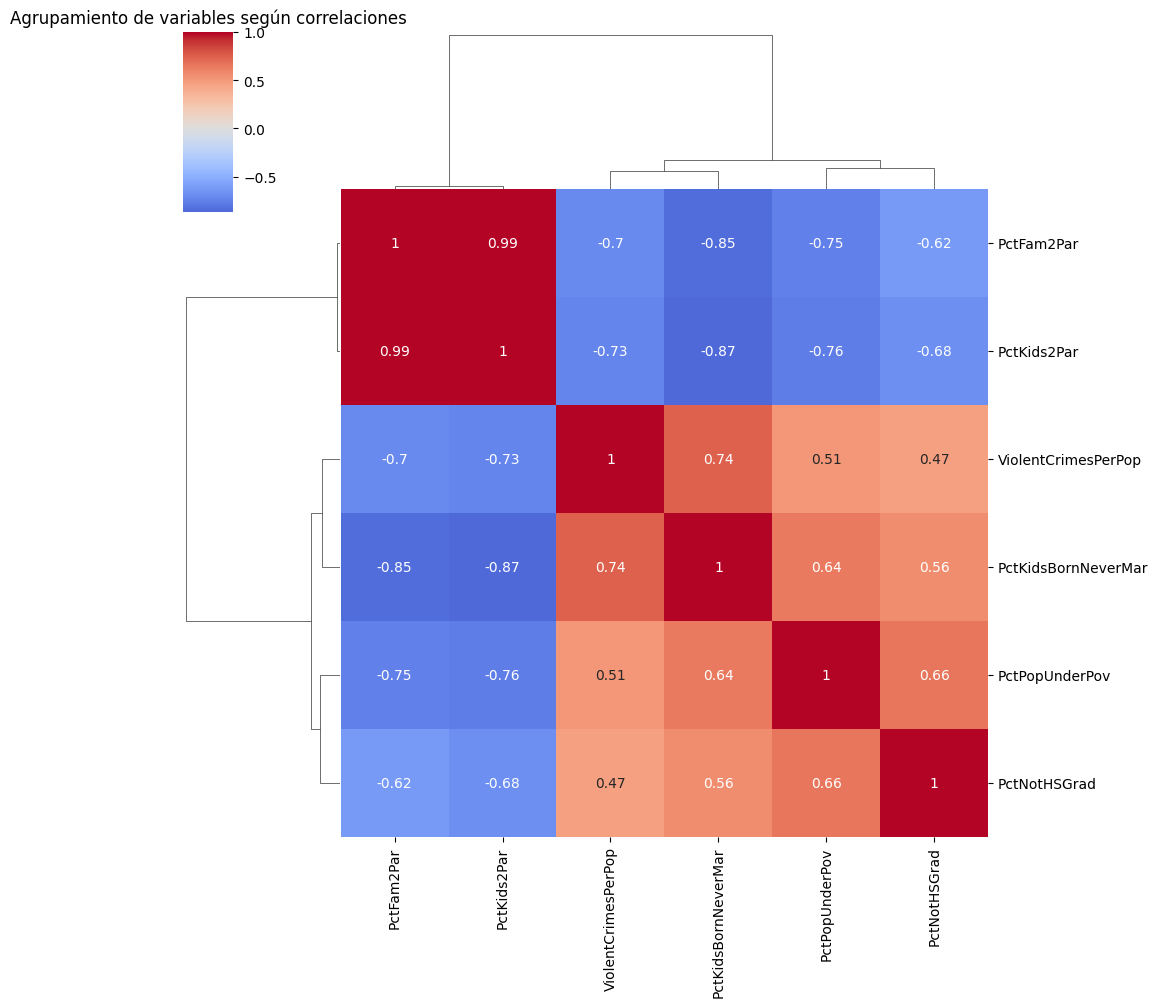

In [38]:
sns.clustermap(df_Col_final[selected].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Agrupamiento de variables según correlaciones')

Estos resultados refuerzan la idea de que los patrones de criminalidad emergen de interacciones entre múltiples dimensiones sociales, más que de factores aislados.

## ¿Podemos predecir correctamente comunidades con alta tasa de crímenes violentos?

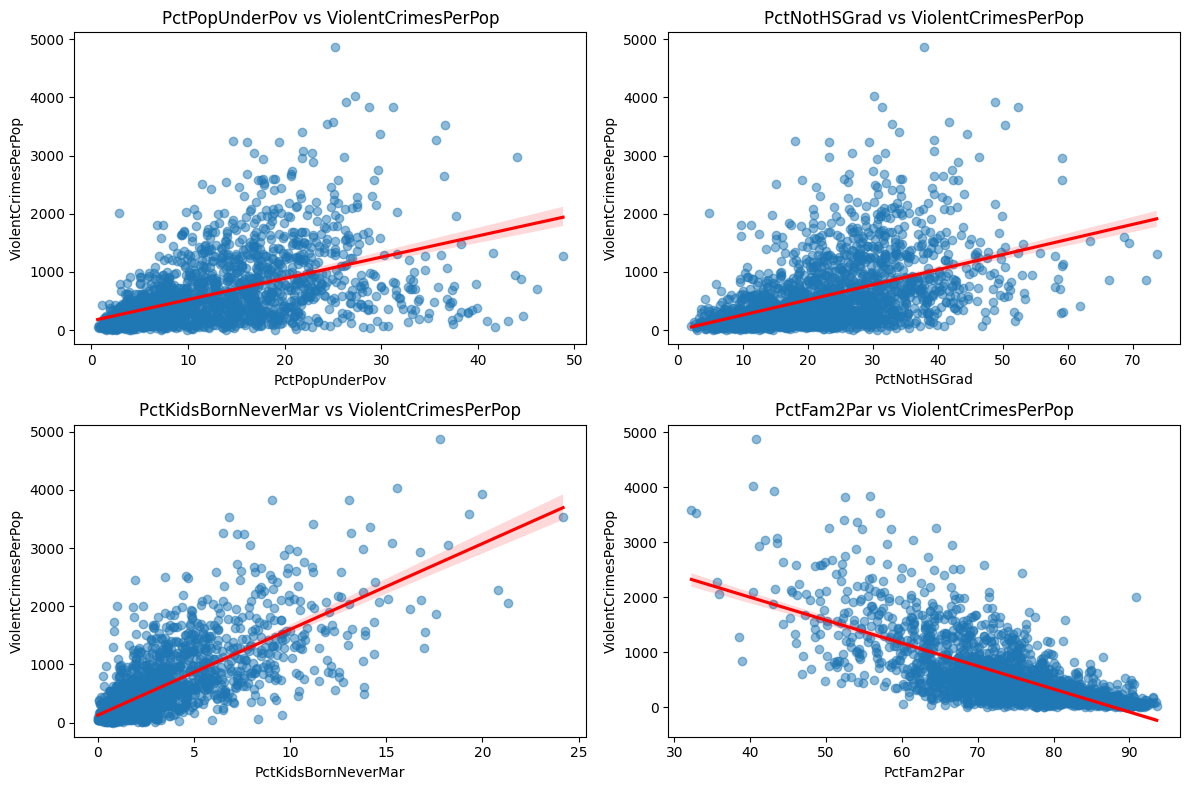

In [50]:
features = ['PctPopUnderPov', 'PctNotHSGrad', 'PctKidsBornNeverMar', 'PctFam2Par']
plt.figure(figsize=(12,8))
for i, f in enumerate(features, 1):
    plt.subplot(2,2,i)
    sns.regplot(x=df_Col_final[f], y=df_Col_final['ViolentCrimesPerPop'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'{f} vs ViolentCrimesPerPop')
plt.tight_layout()
plt.show()

Los gráficos de dispersión muestran relaciones claras entre la tasa de crímenes violentos y las condiciones socioeconómicas de las comunidades.
A medida que aumentan la pobreza, el bajo nivel educativo y la proporción de niños de padres no casados, se incrementa la violencia.
En contraste, una mayor proporción de familias biparentales se asocia con una reducción significativa del crimen.

En conjunto, estos resultados confirman que la desigualdad, la educación y la estructura familiar son variables determinantes en los niveles de criminalidad violenta, y deben considerarse como dimensiones interdependientes del riesgo social.

# Insights

- La violencia no está distribuida de forma uniforme; se concentra en comunidades específicas.
- Los factores económicos, educativos y familiares explican gran parte de la variación en los niveles de crimen.
- La criminalidad es un fenómeno multidimensional, influido por la interacción de factores sociales.


# Conclusiones finales

El análisis evidencia que la criminalidad violenta está fuertemente condicionada por factores sociales y estructurales.
Las comunidades más vulnerables —caracterizadas por bajos ingresos, bajo nivel educativo y estructuras familiares inestables— concentran las tasas más altas de delitos violentos.

A su vez, los entornos con mayor estabilidad familiar y educativa presentan una clara disminución de la violencia.

En consecuencia, las políticas de prevención deberían abordarse de forma integral, combinando estrategias económicas, educativas y sociales que reduzcan la vulnerabilidad y fortalezcan el tejido comunitario.

***Recomendación clave:***
las estrategias de prevención deberían priorizar un enfoque multidimensional, combinando políticas educativas, económicas y comunitarias para reducir las condiciones que facilitan la violencia.